# 5.4 GMM Distribution Analysis of Latent Dimensions

This notebook analyzes the distribution of each *active* latent dimension to determine if it is better modeled as:
- **Unimodal (Single Gaussian)**: Likely representing a continuous factor or noise.
- **Bimodal (Mixture of 2 Gaussians)**: Potentially representing a discrete subtype or categorical factor.

## Methodology
1. **Load Active Dimensions**: Use the same filtering logic as 5.1.1 (KL > Threshold).
2. **Fit GMMs**: For each dimension $d$, fit GMM($k=1$) and GMM($k=2$).
3. **Model Selection**: Compare models using the **Bayesian Information Criterion (BIC)**.
   - $\Delta BIC = BIC(k=1) - BIC(k=2)$
   - If $\Delta BIC > 10$ (positive evidence), the dimension is classified as **Bimodal**.
4. **Visualization**: Plot histograms with GMM overlays for the top bimodal candidates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy import stats
from scipy.stats import pointbiserialr, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4e' % x)

## 1. Data Loading & Active Unit Filtering

In [2]:
# --- PARAMETERS ---
TARGET_BETA = "3.00e-05"
KL_THRESHOLD = 0.05
LATENT_CSV = "output/final_train_combined_vae_data.csv"
KL_CSV_PATH = f"output/Experiments/BetaScanVAE/beta_scan_results/beta_{TARGET_BETA}/kl_divergence.csv"

# Load Data
if os.path.exists(LATENT_CSV):
    df_latent = pd.read_csv(LATENT_CSV)
    print(f"Loaded Latent Data: {df_latent.shape}")
else:
    raise FileNotFoundError(f"Latent data not found at {LATENT_CSV}")

# Determine Active Dimensions
DIM_COLS = [c for c in df_latent.columns if c.startswith('latent_')]
active_features = []

if os.path.exists(KL_CSV_PATH):
    print(f"Loading KL Divergence from: {KL_CSV_PATH}")
    df_kl = pd.read_csv(KL_CSV_PATH)
    for _, row in df_kl.iterrows():
        if row['mean_kl'] > KL_THRESHOLD:
            active_features.append(row['dimension'])
else:
    print("Using Latent Variance as proxy for activity.")
    variances = df_latent[DIM_COLS].var()
    for dim, var in variances.items():
        if var > KL_THRESHOLD:
            active_features.append(dim)

ACTIVE_FEATURES = sorted(active_features, key=lambda x: int(x.split('_')[1]))
print(f"Active Dimensions: {len(ACTIVE_FEATURES)} / {len(DIM_COLS)}")

Loaded Latent Data: (2373, 303)
Using Latent Variance as proxy for activity.
Active Dimensions: 70 / 256


## 2. GMM Fitting & Bimodality Detection

In [3]:
gmm_results = []

print("Fitting GMMs for Active Dimensions...")

for dim in ACTIVE_FEATURES:
    X = df_latent[[dim]].values # Reshape for sklearn
    
    # Fit k=1 (Unimodal)
    gmm1 = GaussianMixture(n_components=1, random_state=42)
    gmm1.fit(X)
    bic1 = gmm1.bic(X)
    
    # Fit k=2 (Bimodal)
    gmm2 = GaussianMixture(n_components=2, random_state=42)
    gmm2.fit(X)
    bic2 = gmm2.bic(X)
    
    # Calculate Delta BIC
    # Positive Delta -> BIC(1) > BIC(2) -> k=2 is better (lower BIC)
    delta_bic = bic1 - bic2
    
    is_bimodal = delta_bic > 10 # Threshold for strong evidence
    
    gmm_results.append({
        'Dimension': dim,
        'BIC_1': bic1,
        'BIC_2': bic2,
        'Delta_BIC': delta_bic,
        'Is_Bimodal': is_bimodal,
        'Means_k2': gmm2.means_.flatten(),
        'Weights_k2': gmm2.weights_.flatten()
    })

df_gmm = pd.DataFrame(gmm_results)
df_gmm = df_gmm.sort_values('Delta_BIC', ascending=False).reset_index(drop=True)

print("\nTop 10 Bimodal Candidates (Highest Delta BIC):")
print(df_gmm[['Dimension', 'Delta_BIC', 'Is_Bimodal']].head(10))

Fitting GMMs for Active Dimensions...

Top 10 Bimodal Candidates (Highest Delta BIC):
    Dimension  Delta_BIC  Is_Bimodal
0   latent_94 4.6646e+02        True
1   latent_67 1.7458e+02        True
2   latent_23 1.6302e+02        True
3  latent_126 1.3631e+02        True
4  latent_209 1.3290e+02        True
5   latent_39 1.1194e+02        True
6   latent_90 1.0374e+02        True
7  latent_197 9.5898e+01        True
8   latent_10 8.7938e+01        True
9  latent_114 8.5703e+01        True


In [4]:
# Analyze separation between GMM components for bimodal dimensions
print("\nComponent Separation Analysis:\n")

separation_results = []
for idx in range(min(10, len(df_gmm[df_gmm['Is_Bimodal']]))):
    row = df_gmm[df_gmm['Is_Bimodal']].iloc[idx]
    dim = row['Dimension']
    means = row['Means_k2']
    weights = row['Weights_k2']
    
    # Calculate separation (distance between means)
    separation = abs(means[1] - means[0])
    
    # Get standard deviations from GMM
    X = df_latent[[dim]].values
    gmm2 = GaussianMixture(n_components=2, random_state=42)
    gmm2.fit(X)
    stds = np.sqrt(gmm2.covariances_.flatten())
    
    # Calculate separation in terms of standard deviations
    avg_std = np.mean(stds)
    separation_in_stds = separation / avg_std if avg_std > 0 else 0
    
    separation_results.append({
        'Dimension': dim,
        'Mean_1': means[0],
        'Mean_2': means[1],
        'Separation': separation,
        'Separation_in_STDs': separation_in_stds,
        'Weight_1': weights[0],
        'Weight_2': weights[1]
    })

df_separation = pd.DataFrame(separation_results)
print(df_separation.to_string())


Component Separation Analysis:

    Dimension      Mean_1      Mean_2  Separation  Separation_in_STDs   Weight_1   Weight_2
0   latent_94  1.0499e+00  6.4111e-01  4.0874e-01          7.0429e-01 8.7013e-01 1.2987e-01
1   latent_67  2.3390e-01  1.8339e-01  5.0516e-02          1.6614e-01 3.8920e-01 6.1080e-01
2   latent_23 -3.6066e-01 -1.3965e-01  2.2101e-01          4.8982e-01 3.5383e-01 6.4617e-01
3  latent_126  1.4391e-01 -1.6124e+00  1.7563e+00          1.5659e+00 6.6640e-01 3.3360e-01
4  latent_209  2.0435e-02 -4.3791e-03  2.4815e-02          8.8640e-02 6.1785e-01 3.8215e-01
5   latent_39 -1.1420e+00 -1.3193e+00  1.7729e-01          1.9219e-01 4.2514e-01 5.7486e-01
6   latent_90  3.3178e-01  2.2331e-01  1.0847e-01          3.6984e-01 4.1669e-01 5.8331e-01
7  latent_197  2.4333e-01 -2.1547e-02  2.6488e-01          6.9289e-01 3.6015e-01 6.3985e-01
8   latent_10 -4.4444e-01  3.4003e-01  7.8447e-01          1.2893e+00 3.4693e-01 6.5307e-01
9  latent_114  4.6676e-03 -1.7135e-01  1.7602e-

## 3. Visualization of Top Bimodal Dimensions

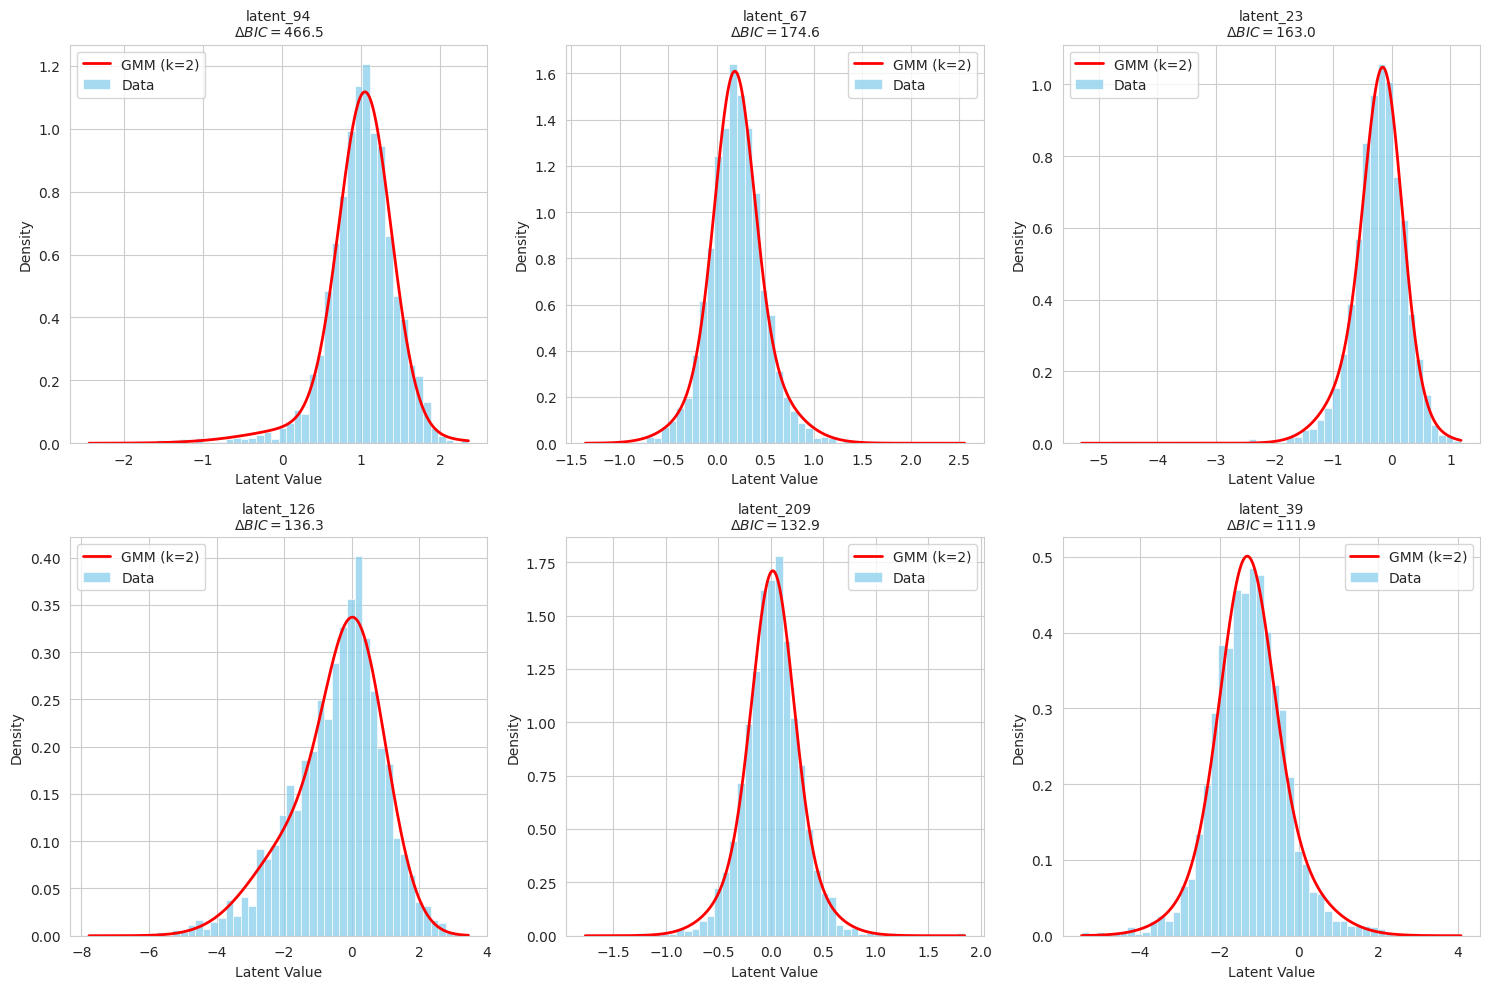

Saved plot to output/gmm_top_bimodal_dimensions.png


In [5]:
top_bimodal = df_gmm[df_gmm['Is_Bimodal']].head(6)['Dimension'].tolist()

if len(top_bimodal) > 0:
    plt.figure(figsize=(15, 10))
    for i, dim in enumerate(top_bimodal):
        plt.subplot(2, 3, i+1)
        
        # Plot Histogram
        sns.histplot(df_latent[dim], kde=False, stat="density", bins=50, color='skyblue', label='Data')
        
        # Plot GMM Overlay
        X_plot = np.linspace(df_latent[dim].min(), df_latent[dim].max(), 1000).reshape(-1, 1)
        gmm2 = GaussianMixture(n_components=2, random_state=42).fit(df_latent[[dim]])
        logprob = gmm2.score_samples(X_plot)
        pdf = np.exp(logprob)
        
        plt.plot(X_plot, pdf, '-r', linewidth=2, label='GMM (k=2)')
        plt.title(f"{dim}\n$\Delta BIC = {df_gmm[df_gmm['Dimension']==dim]['Delta_BIC'].values[0]:.1f}$", fontsize=10)
        plt.xlabel("Latent Value")
        plt.legend()
        
    plt.tight_layout()
    plt.savefig("output/gmm_top_bimodal_dimensions.png")
    plt.show()
    print("Saved plot to output/gmm_top_bimodal_dimensions.png")
else:
    print("No dimensions classified as bimodal.")

### Statistical Validation

In [6]:
print("Statistical Validation of Top Bimodal Dimensions:\n")
validation_results = []
for idx in range(min(5, len(df_gmm))):
    dim = df_gmm.iloc[idx]['Dimension']
    X = df_latent[[dim]].values.flatten()
    
    # Hartigan's dip test would be ideal but requires diptest package
    # Instead, we'll use kurtosis and skewness
    kurt = stats.kurtosis(X)
    skew = stats.skew(X)
    
    # Bimodal distributions typically have negative kurtosis
    validation_results.append({
        'Dimension': dim,
        'Kurtosis': kurt,
        'Skewness': skew,
        'Bimodal_Indicator': 'Yes' if kurt < -0.5 else 'Maybe'
    })
    
df_validation = pd.DataFrame(validation_results)
print(df_validation)

Statistical Validation of Top Bimodal Dimensions:

    Dimension   Kurtosis    Skewness Bimodal_Indicator
0   latent_94 7.4384e+00 -1.5370e+00             Maybe
1   latent_67 5.1266e+00  5.9931e-01             Maybe
2   latent_23 8.5398e+00 -1.1753e+00             Maybe
3  latent_126 9.1284e-01 -6.6789e-01             Maybe
4  latent_209 3.8589e+00 -5.2693e-02             Maybe


## 4. Bimodal Dimension Interpretation (Factor Analysis)

To understand *what* is driving the bimodality in these dimensions, we check their association with known factors:
- **Biological**: Age, Sex, Handedness
- **Pathological**: SBR (we calculate PCA on DATScan regions to get a summary score)
- **Technical**: Scanner Manufacturer

This helps us decide if a bimodal dimension is a useful biomarker (e.g., linked to SBR) or a confounder (e.g., linked to Scanner).

In [13]:
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

# Filter to rows with complete SBR data
df_with_sbr = df_latent.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2373

SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%

Final dataset: (2373, 306)
Unique patients: 1437


In [14]:
# 2. Define Factors
FACTORS = {
    'Age': {'col': 'AGE_AT_VISIT', 'type': 'continuous'},
    'Sex': {'col': 'SEX', 'type': 'binary'},
    'Handedness': {'col': 'HANDED', 'type': 'categorical'},
    'Scanner': {'col': 'Manufacturer', 'type': 'categorical'},
    'Scanner Model': {'col': 'ManufacturerModelName', 'type': 'categorical'},
    'SBR_PC1': {'col': 'SBR_PC1', 'type': 'continuous'},
    'SBR_PC2': {'col': 'SBR_PC2', 'type': 'continuous'},
    'SBR_PC3': {'col': 'SBR_PC3', 'type': 'continuous'},
}

print("Factor preparation complete.")

Factor preparation complete.


In [17]:
# --- Define Correlation/Association Functions ---

def get_best_association(feature_col, df):
    """
    Calculates the association between a latent dimension and all defined factors.
    Returns the factor with the strongest association.
    """
    best_factor = None
    best_score = -1
    best_p = 1.0
    
    # Extract feature data
    x = df[feature_col].values
    
    for factor_name, config in FACTORS.items():
        y = df[config['col']].values
        
        # Clean NaNs
        mask = ~(np.isnan(x) | pd.isnull(y))
        if mask.sum() < 3: 
            continue
            
        x_clean = x[mask]
        y_clean = y[mask]
        
        score = 0
        p_val = 1.0
        
        try:
            if config['type'] == 'continuous':
                # Pearson Correlation
                r, p = stats.pearsonr(x_clean, y_clean.astype(float))
                score = r**2  # Changed from abs(r) to r²
                p_val = p
                
            elif config['type'] == 'binary':
                # Point-Biserial Correlation
                r, p = pointbiserialr(y_clean.astype(float), x_clean)
                score = r**2  # Changed from abs(r) to r²
                p_val = p
                
            elif config['type'] == 'categorical':
                # Eta-Squared (ANOVA)
                cats = np.unique(y_clean)
                if len(cats) < 2: continue
                
                groups = [x_clean[y_clean == c] for c in cats]
                f_stat, p = stats.f_oneway(*groups)
                
                # Calculate Eta-Squared
                grand_mean = x_clean.mean()
                ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
                ss_total = sum((x_clean - grand_mean)**2)
                score = ss_between / ss_total if ss_total > 0 else 0
                score = np.sqrt(score) # Square root to make comparable to r
                p_val = p
                
            # Update best factor
            if score > best_score:
                best_score = score
                best_factor = factor_name
                best_p = p_val
                
        except Exception as e:
            continue

    return best_factor, best_score, best_p

In [25]:
# --- Analyze Bimodal Dimensions ---

analysis_results = []
print("Analyzing Factor Associations for Bimodal Dimensions...")

# Iterate through the bimodal dimensions identified in the previous step
bimodal_dims = df_gmm[df_gmm['Is_Bimodal']]['Dimension'].tolist()

for dim in bimodal_dims:
    factor, score, p_val = get_best_association(dim, df_final)
    
    analysis_results.append({
        'Dimension': dim,
        'Delta_BIC': df_gmm[df_gmm['Dimension'] == dim]['Delta_BIC'].values[0],
        'Best_Factor': factor,
        'Association_Score': score, # |r| or sqrt(eta^2)
        'P_Value': p_val
    })

df_analysis = pd.DataFrame(analysis_results)
df_analysis = df_analysis.sort_values('Delta_BIC', ascending=False).reset_index(drop=True)

# Group by the Factor found
print("\n--- Dimensions Grouped by Factor ---")
for factor, group in df_analysis.groupby('Best_Factor'):
    print(f"\nFACTOR: {factor} (Count: {len(group)})")
    
    # Sort by association score within the factor to see the strongest links first
    sorted_group = group.sort_values('Association_Score', ascending=False)
    
    print(sorted_group[['Dimension', 'Association_Score', 'P_Value']].to_string(index=False))

Analyzing Factor Associations for Bimodal Dimensions...

--- Dimensions Grouped by Factor ---

FACTOR: SBR_PC1 (Count: 1)
 Dimension  Association_Score    P_Value
latent_126         8.3656e-01 0.0000e+00

FACTOR: Scanner Model (Count: 22)
 Dimension  Association_Score    P_Value
 latent_39         4.5456e-01 2.3439e-99
latent_231         3.5783e-01 1.3284e-53
latent_163         2.9759e-01 7.3804e-33
 latent_17         2.9577e-01 2.5892e-32
latent_209         2.8851e-01 3.3916e-30
 latent_90         2.8281e-01 1.3775e-28
 latent_23         2.8006e-01 7.9622e-28
 latent_18         2.7471e-01 2.2301e-26
latent_207         2.7292e-01 6.6731e-26
latent_222         2.6645e-01 3.1989e-24
latent_214         2.6103e-01 7.4241e-23
latent_107         2.5400e-01 3.7732e-21
latent_114         2.5131e-01 1.6341e-20
latent_197         2.4398e-01 7.8050e-19
 latent_10         2.4181e-01 2.3716e-18
 latent_94         2.3002e-01 7.7040e-16
latent_147         2.0513e-01 3.6521e-11
 latent_96         1.96

In [26]:
# List to store ALL results
full_results = []

print("Calculating full association matrix...")

# Iterate through bimodal dimensions
for dim in bimodal_dims:
    # Get the data for this dimension
    x = df_final[dim].values
    
    # Create a dictionary to store results for this single dimension
    row_data = {'Dimension': dim}
    
    for factor_name, config in FACTORS.items():
        y = df_final[config['col']].values
        
        # Clean NaNs
        mask = ~(np.isnan(x) | pd.isnull(y))
        if mask.sum() < 3: 
            row_data[factor_name] = 0.0 # Default to 0 if not enough data
            continue
            
        x_clean = x[mask]
        y_clean = y[mask]
        
        score = 0
        
        try:
            if config['type'] == 'continuous':
                r, _ = stats.pearsonr(x_clean, y_clean.astype(float))
                score = r**2
            elif config['type'] == 'binary':
                r, _ = stats.pointbiserialr(y_clean.astype(float), x_clean)
                score = r**2
            elif config['type'] == 'categorical':
                # Eta-squared calculation
                cats = np.unique(y_clean)
                if len(cats) >= 2:
                    groups = [x_clean[y_clean == c] for c in cats]
                    grand_mean = x_clean.mean()
                    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
                    ss_total = sum((x_clean - grand_mean)**2)
                    score = np.sqrt(ss_between / ss_total) if ss_total > 0 else 0
        except:
            score = 0
            
        # Store the score for this factor
        row_data[factor_name] = score

    full_results.append(row_data)

# Create the detailed DataFrame
df_heatmap = pd.DataFrame(full_results)

# Display the results
print("\n--- Association Scores for All Factors (First 10 Rows) ---")
print(df_heatmap.head(10).to_string(index=False))


Calculating full association matrix...

--- Association Scores for All Factors (First 10 Rows) ---
 Dimension        Age        Sex  Handedness    Scanner  Scanner Model    SBR_PC1    SBR_PC2    SBR_PC3
 latent_94 1.6995e-02 8.4314e-03  3.4565e-02 2.0388e-01     2.3002e-01 2.3319e-02 3.2932e-03 3.7529e-02
 latent_67 6.3984e-03 7.9076e-04  4.6413e-02 1.5729e-01     1.7380e-01 6.2213e-04 1.7923e-03 1.4754e-03
 latent_23 7.6181e-06 1.4229e-03  5.8492e-02 2.6444e-01     2.8006e-01 5.1730e-04 1.0335e-02 2.4003e-02
latent_126 2.5506e-02 1.4207e-03  3.8265e-02 3.4533e-01     3.6748e-01 8.3656e-01 6.6703e-03 7.4492e-03
latent_209 4.7632e-03 8.6341e-03  1.0000e-02 2.4511e-01     2.8851e-01 9.7619e-03 8.1325e-03 3.2572e-02
 latent_39 2.0381e-02 4.4240e-03  2.4202e-02 4.2232e-01     4.5456e-01 1.6117e-01 2.0634e-02 6.3084e-03
 latent_90 7.5385e-03 2.0747e-03  3.9228e-02 2.5059e-01     2.8281e-01 8.0515e-03 2.3146e-04 1.8753e-02
latent_197 7.3936e-03 7.0203e-03  5.0409e-02 1.9548e-01     2.4398e-0

In [27]:
# 1. Melt the dataframe to long format for easier plotting
df_long = df_heatmap.melt(id_vars='Dimension', var_name='Factor', value_name='Score')

# 2. Sort by Score so the plots look organized
df_long = df_long.sort_values('Score', ascending=False)

## 5. Visualization with Confidence Intervals

#### Confidence Intervals

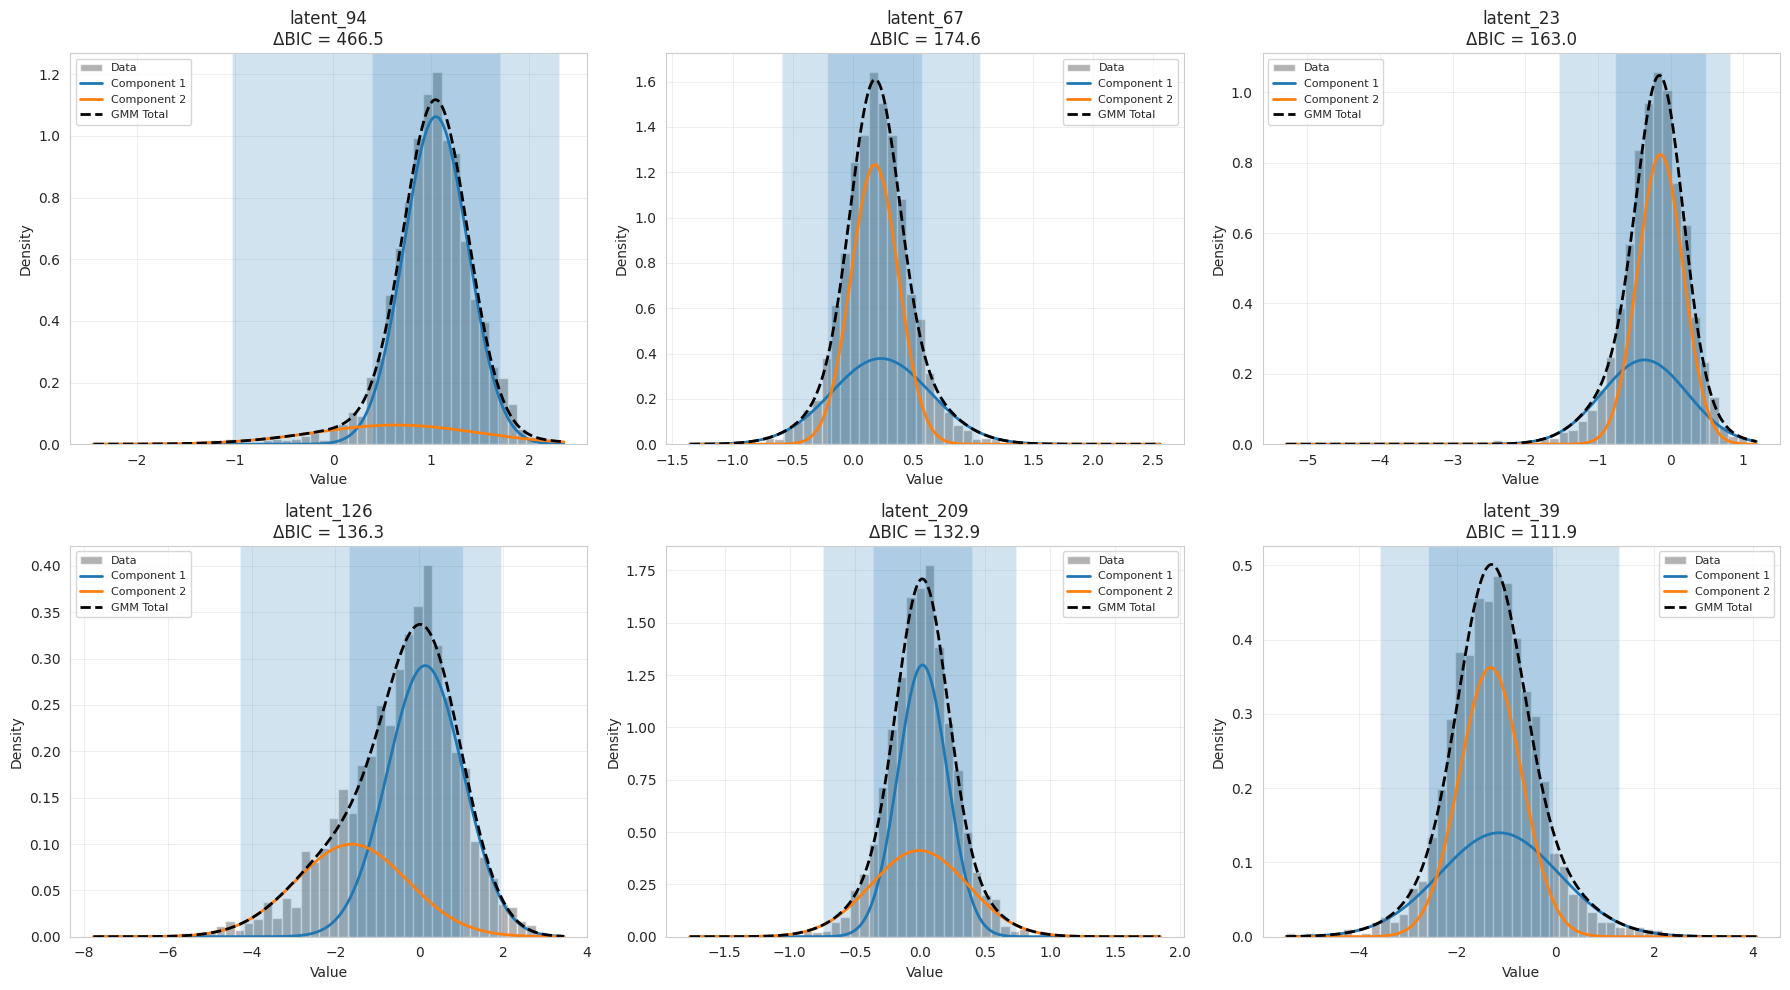

In [9]:
# Enhanced visualization with confidence intervals
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(min(6, len(df_gmm[df_gmm['Is_Bimodal']]))):
    row = df_gmm[df_gmm['Is_Bimodal']].iloc[idx]
    dim = row['Dimension']
    X = df_latent[[dim]].values.flatten()
    
    # Fit GMM
    gmm2 = GaussianMixture(n_components=2, random_state=42)
    gmm2.fit(X.reshape(-1, 1))
    
    # Plot histogram
    axes[idx].hist(X, bins=50, density=True, alpha=0.6, color='gray', label='Data')
    
    # Plot GMM components with confidence intervals
    x_range = np.linspace(X.min(), X.max(), 1000)
    for i in range(2):
        mean = gmm2.means_[i][0]
        std = np.sqrt(gmm2.covariances_[i][0][0])
        weight = gmm2.weights_[i]
        
        # Component PDF
        component_pdf = weight * stats.norm.pdf(x_range, mean, std)
        axes[idx].plot(x_range, component_pdf, label=f'Component {i+1}', linewidth=2)
        
        # Confidence interval (±2 std)
        axes[idx].axvspan(mean - 2*std, mean + 2*std, alpha=0.2)
    
    # Overall GMM PDF
    overall_pdf = np.exp(gmm2.score_samples(x_range.reshape(-1, 1)))
    axes[idx].plot(x_range, overall_pdf, 'k--', linewidth=2, label='GMM Total')
    
    axes[idx].set_title(f'{dim}\nΔBIC = {row["Delta_BIC"]:.1f}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Comprehensive summary table

In [10]:
# Comprehensive summary table
print("\n=== COMPREHENSIVE SUMMARY ===\n")

summary_data = {
    'Total Active Dimensions': len(ACTIVE_FEATURES),
    'Bimodal Dimensions (ΔBIC > 10)': len(df_gmm[df_gmm['Is_Bimodal']]),
    'Unimodal Dimensions': len(df_gmm[~df_gmm['Is_Bimodal']]),
    'Percentage Bimodal': f"{100 * len(df_gmm[df_gmm['Is_Bimodal']]) / len(ACTIVE_FEATURES):.1f}%",
    'Strongest Bimodal Signal': df_gmm.iloc[0]['Dimension'],
    'Max Delta BIC': df_gmm.iloc[0]['Delta_BIC']
}

for key, value in summary_data.items():
    print(f"{key:.<40} {value}")

print("\n" + "="*60)


=== COMPREHENSIVE SUMMARY ===

Total Active Dimensions................. 70
Bimodal Dimensions (ΔBIC > 10).......... 23
Unimodal Dimensions..................... 47
Percentage Bimodal...................... 32.9%
Strongest Bimodal Signal................ latent_94
Max Delta BIC........................... 466.4577011430065



#### Compare BIC


Model Selection Across Multiple K Values:

   Dimension     BIC_k1     BIC_k2     BIC_k3     BIC_k4     BIC_k5  Optimal_K
0  latent_94 2.9558e+03 2.4894e+03 2.4967e+03 2.5122e+03 2.5399e+03          2
1  latent_67 1.0370e+03 8.6240e+02 8.5583e+02 8.7267e+02 8.9641e+02          3
2  latent_23 2.8994e+03 2.7364e+03 2.7307e+03 2.7464e+03 2.7696e+03          3


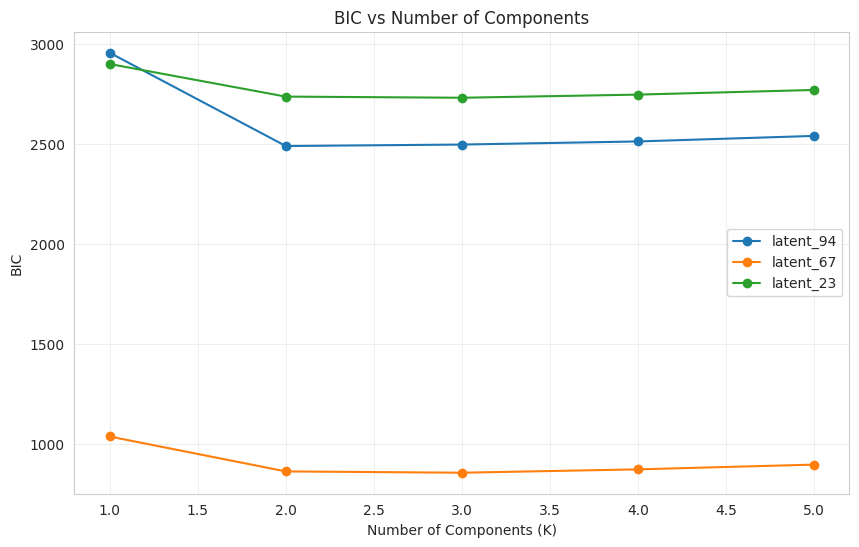

In [11]:
# Compare BIC across different numbers of components
print("\nModel Selection Across Multiple K Values:\n")

k_range = range(1, 6)
comparison_results = []

for idx in range(min(3, len(df_gmm[df_gmm['Is_Bimodal']]))):
    dim = df_gmm[df_gmm['Is_Bimodal']].iloc[idx]['Dimension']
    X = df_latent[[dim]].values
    
    bic_values = []
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(X)
        bic_values.append(gmm.bic(X))
    
    comparison_results.append({
        'Dimension': dim,
        **{f'BIC_k{k}': bic for k, bic in zip(k_range, bic_values)},
        'Optimal_K': k_range[np.argmin(bic_values)]
    })

df_comparison = pd.DataFrame(comparison_results)
print(df_comparison.to_string())

# Visualize BIC curves
fig, ax = plt.subplots(figsize=(10, 6))
for idx, row in df_comparison.iterrows():
    bic_vals = [row[f'BIC_k{k}'] for k in k_range]
    ax.plot(k_range, bic_vals, marker='o', label=row['Dimension'])

ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('BIC')
ax.set_title('BIC vs Number of Components')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

#### The "Top Influencers" (Bar Charts per Factor)

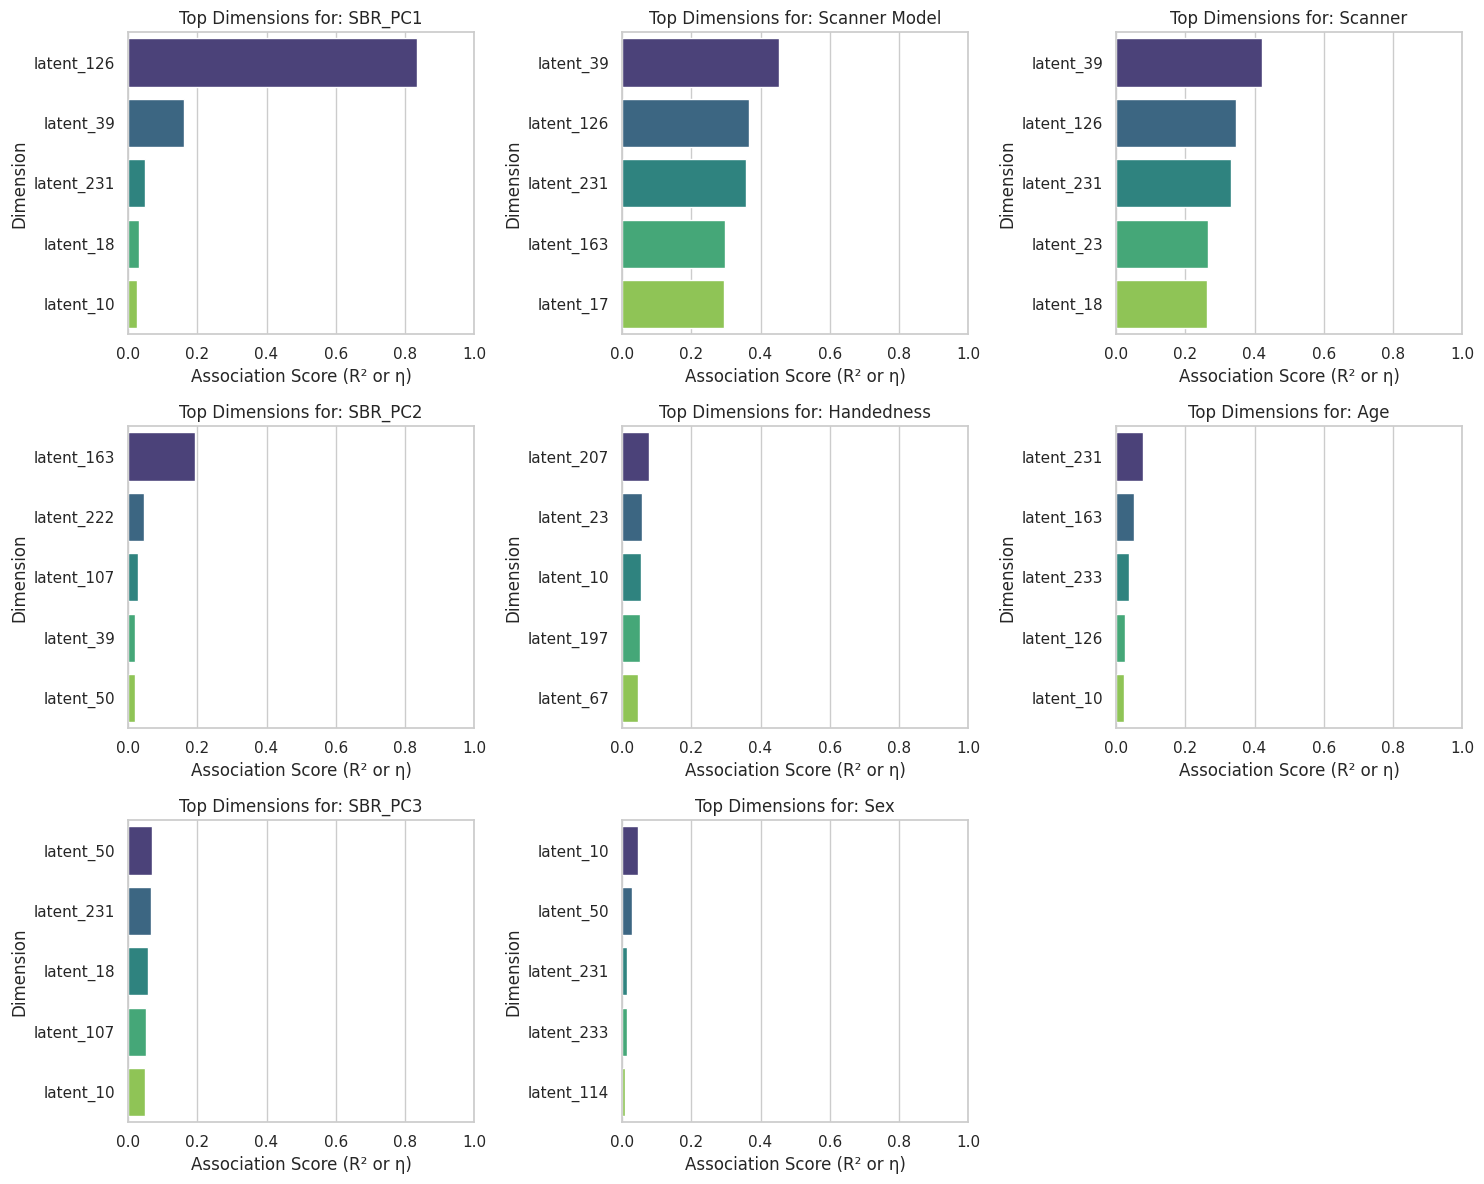

In [28]:
# Settings
top_n = 5  # How many dimensions to show per factor
factors = df_long['Factor'].unique()
num_factors = len(factors)

# Create a grid of subplots
cols = 3
rows = (num_factors // cols) + (1 if num_factors % cols > 0 else 0)
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, factor in enumerate(factors):
    ax = axes[i]
    
    # Filter for this factor and get top N dimensions
    data = df_long[df_long['Factor'] == factor].head(top_n)
    
    # Plot
    sns.barplot(data=data, x='Score', y='Dimension', ax=ax, palette='viridis')
    
    ax.set_title(f"Top Dimensions for: {factor}")
    ax.set_xlabel("Association Score (R² or η)")
    ax.set_xlim(0, 1.0) # Fixed scale for fair comparison

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### The Global Impact

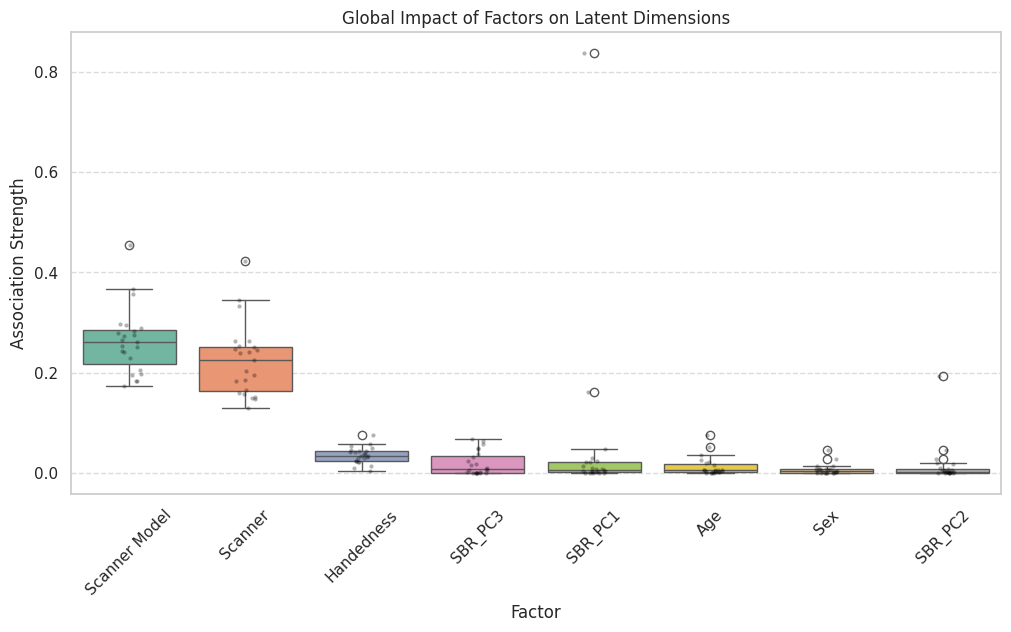

In [29]:
plt.figure(figsize=(12, 6))

# Sort factors by their median influence
sorted_factors = df_long.groupby('Factor')['Score'].median().sort_values(ascending=False).index

sns.boxplot(data=df_long, x='Factor', y='Score', order=sorted_factors, palette="Set2")
sns.stripplot(data=df_long, x='Factor', y='Score', order=sorted_factors, 
              color='black', alpha=0.3, jitter=True, size=3)

plt.title("Global Impact of Factors on Latent Dimensions")
plt.ylabel("Association Strength")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Verify the Data

In [31]:
def plot_specific_association(dim_name, factor_name, df, config):
    plt.figure(figsize=(8, 5))
    
    # Drop NaNs for plotting
    plot_data = df[[dim_name, factor_name]].dropna()
    
    if config['type'] == 'continuous':
        # Scatter plot with regression line
        sns.regplot(data=plot_data, x=factor_name, y=dim_name, 
                    scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        
    elif config['type'] in ['categorical', 'binary']:
        # Box plot or Violin plot
        sns.boxplot(data=plot_data, x=factor_name, y=dim_name)
        sns.stripplot(data=plot_data, x=factor_name, y=dim_name, 
                      color='black', alpha=0.3, jitter=True)
        plt.xticks(rotation=45)
        
    plt.title(f"{dim_name} vs. {factor_name}")
    plt.grid(True, alpha=0.3)
    plt.show()

--- Plotting Best Dimension for Each Factor ---

Factor: Age
  -> Best Match: latent_231
  -> Score: 0.0761


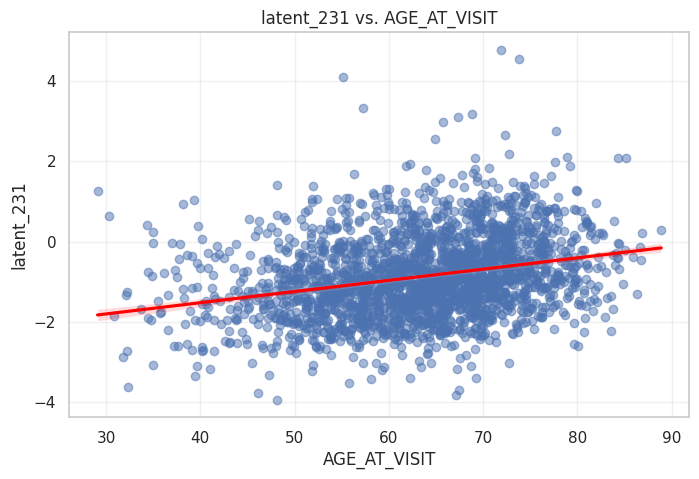

--------------------------------------------------
Factor: Sex
  -> Best Match: latent_10
  -> Score: 0.0462


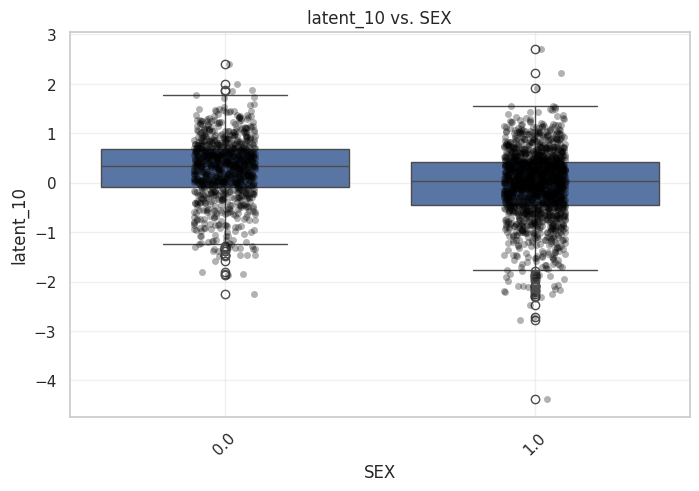

--------------------------------------------------
Factor: Handedness
  -> Best Match: latent_207
  -> Score: 0.0762


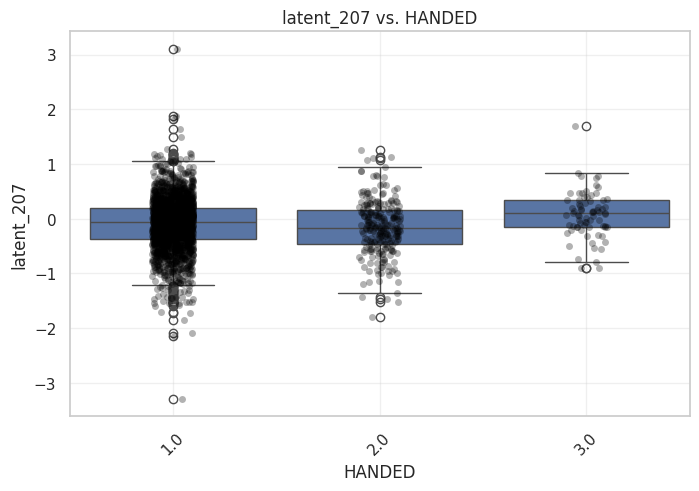

--------------------------------------------------
Factor: Scanner
  -> Best Match: latent_39
  -> Score: 0.4223


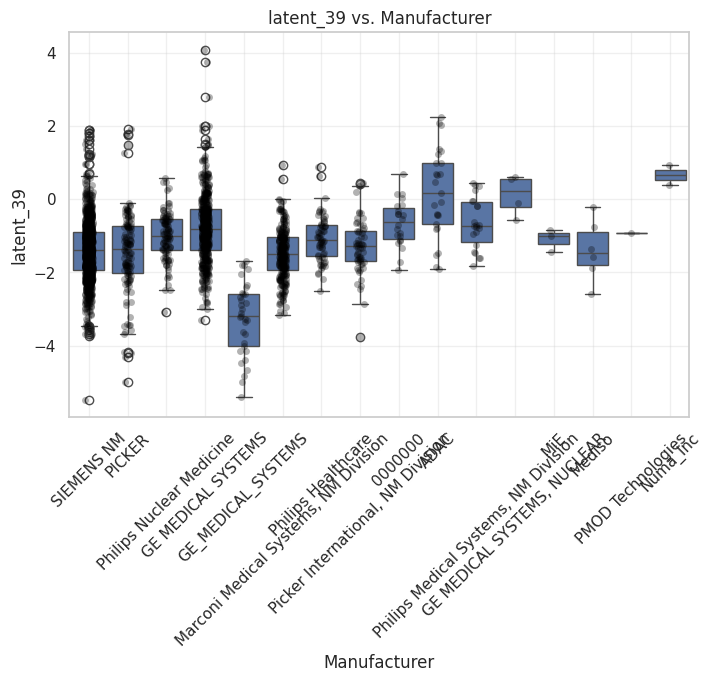

--------------------------------------------------
Factor: Scanner Model
  -> Best Match: latent_39
  -> Score: 0.4546


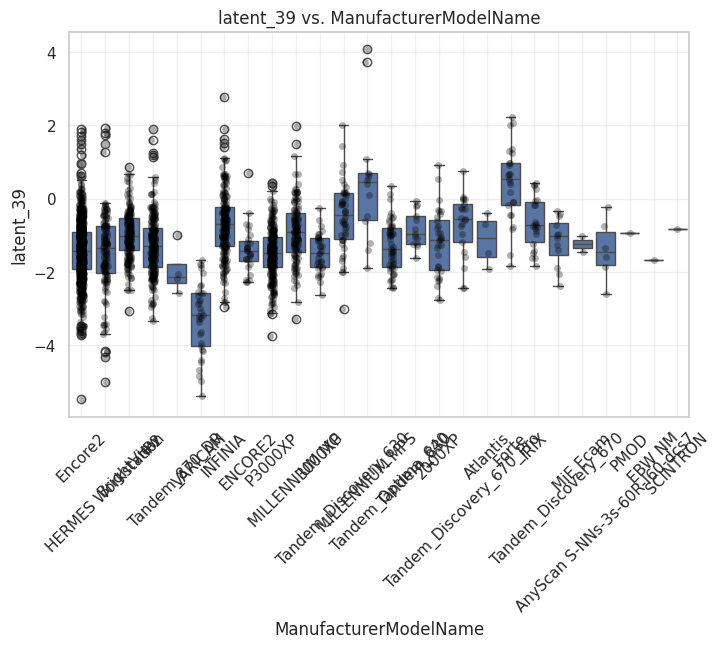

--------------------------------------------------
Factor: SBR_PC1
  -> Best Match: latent_126
  -> Score: 0.8366


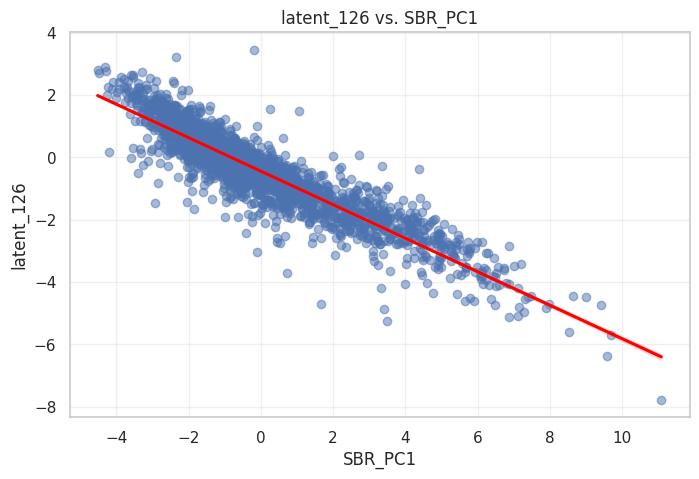

--------------------------------------------------
Factor: SBR_PC2
  -> Best Match: latent_163
  -> Score: 0.1942


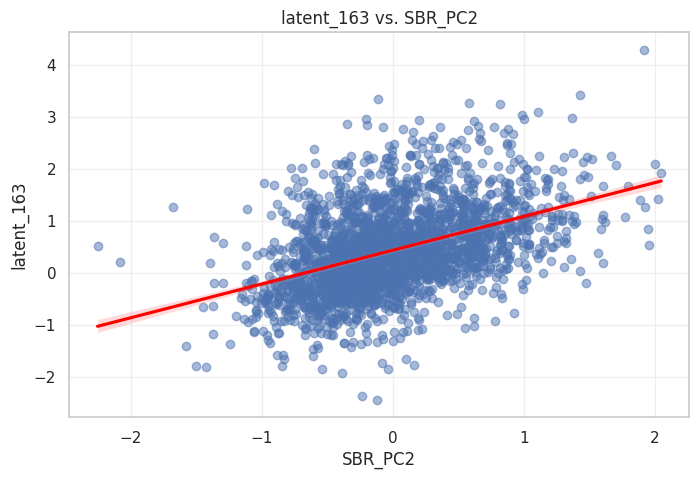

--------------------------------------------------
Factor: SBR_PC3
  -> Best Match: latent_50
  -> Score: 0.0674


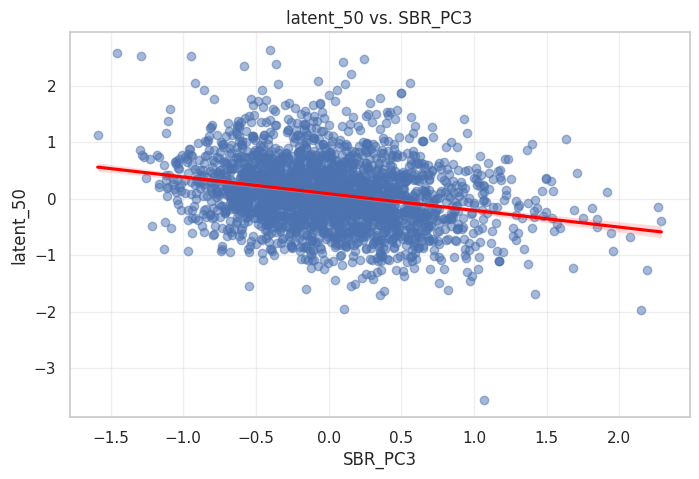

--------------------------------------------------


In [35]:
# 1. Ensure you have the 'FACTORS' dictionary and 'df_heatmap' from previous steps
#    (df_heatmap is the table where rows=dimensions, columns=factors)

print("--- Plotting Best Dimension for Each Factor ---\n")

for factor_name, config in FACTORS.items():
    
    # 1. Find the dimension with the max score for this factor
    #    idxmax() returns the index (Dimension name) with the highest value
    best_row_index = df_heatmap[factor_name].idxmax()
    
    # Extract the name and the score
    best_dim = df_heatmap.loc[best_row_index, 'Dimension']
    best_score = df_heatmap.loc[best_row_index, factor_name]
    
    # 2. Check if the association is meaningful (optional threshold)
    if best_score == 0:
        print(f"Skipping {factor_name}: No valid associations found.")
        continue

    print(f"Factor: {factor_name}")
    print(f"  -> Best Match: {best_dim}")
    print(f"  -> Score: {best_score:.4f}")
    
    # 3. Call the plotting function
    #    We pass: the dimension name, the column name from your dataframe, the dataframe, and the config type
    plot_specific_association(
        dim_name=best_dim, 
        factor_name=config['col'], # Use the actual dataframe column name (e.g., 'AGE_AT_VISIT')
        df=df_final, 
        config=config
    )
    
    print("-" * 50) # Separator line

## 6. Save Results

In [12]:
output_path_csv = "output/gmm_dimension_analysis.csv"
df_gmm.to_csv(output_path_csv, index=False)
print(f"Full GMM Analysis results saved to: {output_path_csv}")

# Export list of Bimodal Dimensions for next notebook
bimodal_dims = df_gmm[df_gmm['Is_Bimodal']]['Dimension'].tolist()
print(f"\nIdentified {len(bimodal_dims)} Bimodal Dimensions.")

Full GMM Analysis results saved to: output/gmm_dimension_analysis.csv

Identified 23 Bimodal Dimensions.
